# Dummy Latency Comparison

Compares real latency for Razor's Edge objective strategies (`RMS`, `FIFO`, `MINMAX`) and builds the
**Synthetic Latency Comparison with Different Strategies** table used in `PAPER.md`.


In [1]:
from pathlib import Path
import sys
import psutil
import os

repo_root = Path.cwd()

while not (repo_root / "src").exists():
    if repo_root.parent == repo_root:
        raise RuntimeError("Could not find 'src' directory in any parent")
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

p = psutil.Process(os.getpid())
if psutil.WINDOWS:
    p.nice(psutil.HIGH_PRIORITY_CLASS)
else:
    try:
        p.nice(-10)
    except psutil.AccessDenied:
        print("Elevation (sudo) is required to set high priority on Unix.")

In [2]:
import asyncio
import time
import random
import matplotlib.pyplot as plt
from collections import defaultdict

from src.executor.process_manager import ComputeExecutor
from demos.real.razors_edge_gpu_benchmark_task_latency_variants import (
    RazorsEdgeGPUBenchmarkRMSTask,
    RazorsEdgeGPUBenchmarkFIFOTask,
    RazorsEdgeGPUBenchmarkMinMaxTask
)

strategy_tasks = [
    ("RMS", RazorsEdgeGPUBenchmarkRMSTask),
    ("FIFO", RazorsEdgeGPUBenchmarkFIFOTask),
    ("MINMAX", RazorsEdgeGPUBenchmarkMinMaxTask),
]


## Start executor

In [3]:
executor = ComputeExecutor(
    [task for _, task in strategy_tasks],
    async_limit=64,
    model_thread_limit=1,
)
time.sleep(5)


## Basic functionality check

In [4]:
for strategy_name, task in strategy_tasks:
    sample = executor.sync_compute_fn(task, "hello razors edge")
    assert isinstance(sample, list)
    assert len(sample) > 0
    assert isinstance(sample[0], float)
    print(f"sync check passed for {strategy_name}")


sync check passed for RMS
sync check passed for FIFO
sync check passed for MINMAX


## Benchmark helpers

In [5]:
import string


def generate_random_strings(n, a, b, seed=42):
    random.seed(seed)
    chars = string.ascii_letters + string.digits
    result = []
    for _ in range(n):
        length = random.randint(a, b)
        rand_str = ''.join(random.choice(chars) for _ in range(length))
        result.append(rand_str)
    return result


async def benchmark_async(target, max_token_count: int, request_count: int, seed: int) -> tuple[float, float, float, float, float, float]:
    payloads = generate_random_strings(request_count, 1, max_token_count, seed=seed)
    start = time.perf_counter()

    all_times = []

    async def request(payload):
        start_req = time.perf_counter()
        result = await executor.async_compute_fn(target, payload)
        all_times.append(time.perf_counter() - start_req)
        return result

    await asyncio.gather(*(request(payload) for payload in payloads))
    elapsed = time.perf_counter() - start

    all_times.sort()
    p95_idx = min(int(request_count * 0.95), request_count - 1)
    p99_idx = min(int(request_count * 0.99), request_count - 1)

    return (
        request_count / elapsed,
        (sum((x**2 for x in all_times)) / request_count) ** 0.5,
        sum(all_times) / request_count,
        all_times[p95_idx],
        all_times[p99_idx],
        max(all_times),
    )


## Run timing benchmarks and aggregate by strategy


In [6]:
max_token_size = 500
n_req = 200
n_rounds = 5

raw_data = []
for round_idx in range(n_rounds):
    run_order = list(strategy_tasks)
    random.shuffle(run_order)
    for strategy_name, task in run_order:
        await benchmark_async(
            task,
            max_token_size,
            10,
            seed=42 + round_idx,
        )
        rps, rms, avg, p95, p99, max_latency = await benchmark_async(
            task,
            max_token_size,
            n_req,
            seed=42 + round_idx,
        )
        raw_data.append((strategy_name, rps, rms, avg, p95, p99, max_latency))
        print(
            f"round={round_idx + 1} strategy={strategy_name}",
            *(round(i, 4) for i in (rps, rms, avg, p95, p99, max_latency)),
        )
        time.sleep(1)


round=1 strategy=FIFO 88.0244 1.3294 1.1678 2.0946 2.2501 2.2504
round=1 strategy=RMS 88.123 1.2735 1.0835 2.2235 2.2643 2.2647
round=1 strategy=MINMAX 88.6969 1.4994 1.3551 2.184 2.2501 2.2514
round=2 strategy=FIFO 101.0786 1.1551 1.0204 1.8393 1.9724 1.9726
round=2 strategy=RMS 100.7392 1.0673 0.9034 1.871 1.9826 1.9832
round=2 strategy=MINMAX 101.1235 1.3392 1.2089 1.9526 1.9566 1.9729
round=3 strategy=MINMAX 103.115 1.3277 1.2064 1.9141 1.9367 1.9368
round=3 strategy=RMS 98.3277 1.1116 0.9423 1.964 2.0011 2.0317
round=3 strategy=FIFO 100.5681 1.2283 1.0964 1.9542 1.9821 1.9824
round=4 strategy=RMS 94.6702 1.1544 0.9754 2.1059 2.1102 2.1108
round=4 strategy=FIFO 95.2318 1.2465 1.09 2.0177 2.0946 2.0949
round=4 strategy=MINMAX 91.0803 1.4636 1.3234 2.1558 2.1894 2.1897
round=5 strategy=MINMAX 93.0416 1.4693 1.3304 2.102 2.1475 2.1481
round=5 strategy=RMS 95.3058 1.1526 0.9689 2.0535 2.0925 2.0929
round=5 strategy=FIFO 94.9119 1.2444 1.0815 2.0118 2.1016 2.1019


## Synthetic Latency Comparison with Different Strategies

The table below mirrors the `PAPER.md` subsection title and reports:
- throughput (RPS)
- mean latency
- p95 latency
- p99 latency
- max latency

(RMS latency is also retained as a reference metric.)


| Strategy | RPS | RMS Latency | Mean Latency | P95 Latency | P99 Latency | Max Latency |
| --- | --- | --- | --- | --- | --- | --- |
| RMS | 95.433185 | 1.151876 | 0.974708 | 2.043573 | 2.090140 | 2.096659 |
| FIFO | 95.962956 | 1.240765 | 1.091206 | 1.983491 | 2.080144 | 2.080418 |
| MINMAX | 95.411471 | 1.419826 | 1.284810 | 2.061702 | 2.096055 | 2.099771 |


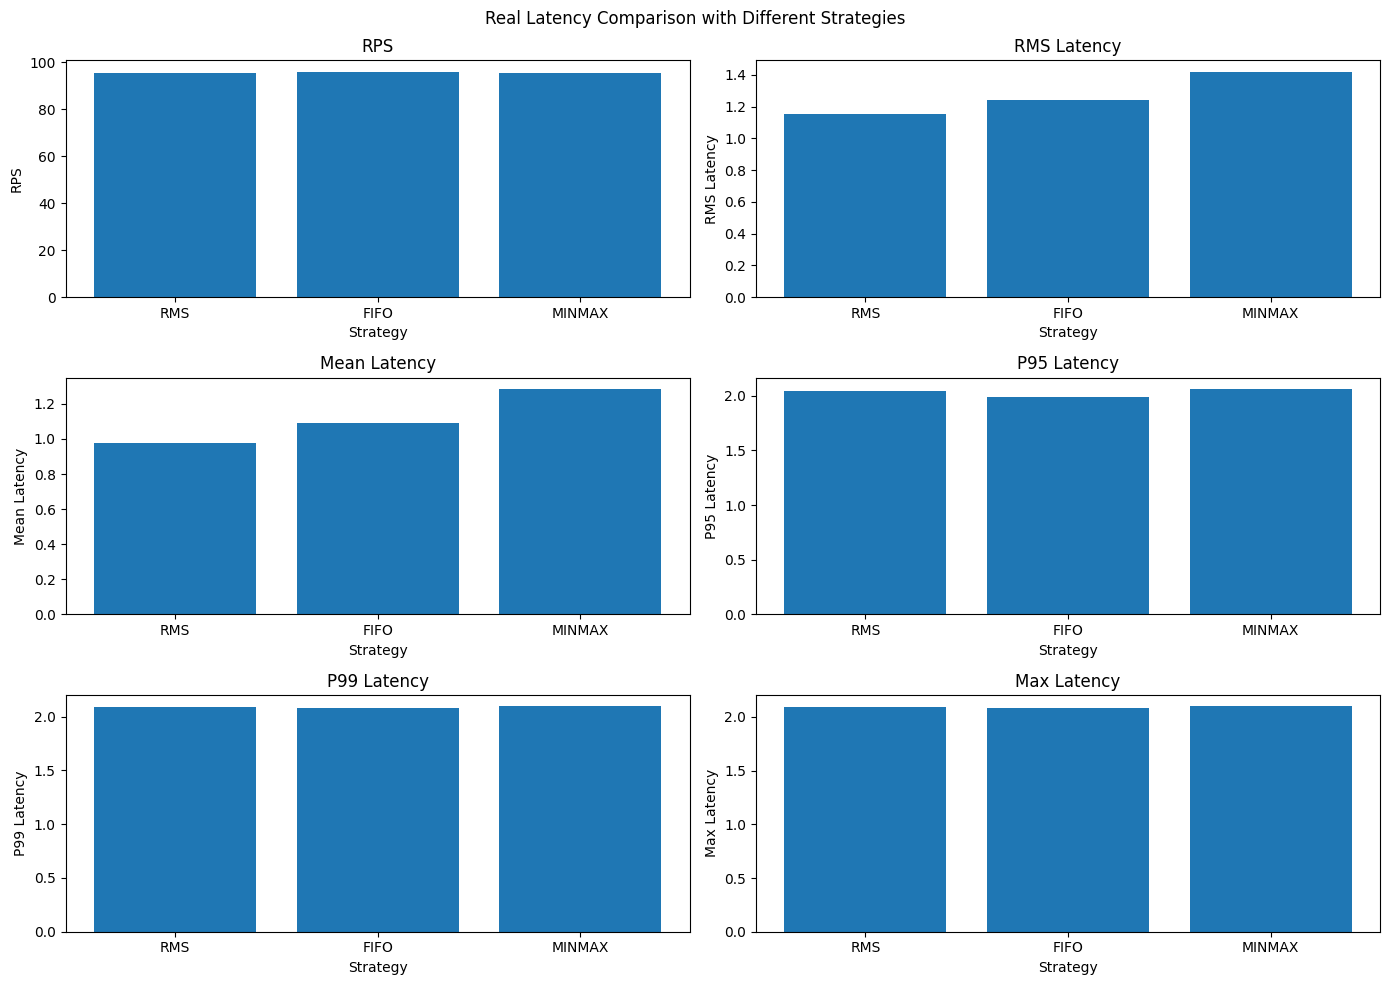

In [7]:
metrics_by_strategy = defaultdict(lambda: defaultdict(list))

for strategy_name, rps, rms, avg, p95, p99, max_latency in raw_data:
    metrics_by_strategy[strategy_name]["RPS"].append(rps)
    metrics_by_strategy[strategy_name]["RMS Latency"].append(rms)
    metrics_by_strategy[strategy_name]["Mean Latency"].append(avg)
    metrics_by_strategy[strategy_name]["P95 Latency"].append(p95)
    metrics_by_strategy[strategy_name]["P99 Latency"].append(p99)
    metrics_by_strategy[strategy_name]["Max Latency"].append(max_latency)

strategy_order = [name for name, _ in strategy_tasks]
metric_order = ["RPS", "RMS Latency", "Mean Latency", "P95 Latency", "P99 Latency", "Max Latency"]

table_rows = []
for strategy_name in strategy_order:
    row = {"Strategy": strategy_name}
    for metric in metric_order:
        values = metrics_by_strategy[strategy_name][metric]
        row[metric] = sum(values) / len(values)
    table_rows.append(row)

header = ["Strategy"] + metric_order
divider = ["---"] * len(header)
lines = [
    "| " + " | ".join(header) + " |",
    "| " + " | ".join(divider) + " |",
]
for row in table_rows:
    lines.append(
        "| " + " | ".join(
            [row["Strategy"]] + [f"{row[m]:.6f}" for m in metric_order]
        ) + " |"
    )

latency_table_markdown = "\n".join(lines)
print(latency_table_markdown)

labels = [row["Strategy"] for row in table_rows]
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, metric in zip(axes, metric_order):
    values = [row[metric] for row in table_rows]
    ax.bar(labels, values)
    ax.set_title(metric)
    ax.set_xlabel("Strategy")
    ax.set_ylabel(metric)

fig.suptitle("Real Latency Comparison with Different Strategies")
plt.tight_layout()
fig.savefig(Path("..") / ".." / "images" / f"{fig.get_suptitle()}.png")
plt.show()


In [8]:
print(latency_table_markdown)


| Strategy | RPS | RMS Latency | Mean Latency | P95 Latency | P99 Latency | Max Latency |
| --- | --- | --- | --- | --- | --- | --- |
| RMS | 95.433185 | 1.151876 | 0.974708 | 2.043573 | 2.090140 | 2.096659 |
| FIFO | 95.962956 | 1.240765 | 1.091206 | 1.983491 | 2.080144 | 2.080418 |
| MINMAX | 95.411471 | 1.419826 | 1.284810 | 2.061702 | 2.096055 | 2.099771 |
